#### 6.6: Workshop 6 - Association Rule Mining – Apriori – MBA

This week’s live workshop will introduce students to Market Basket Analysis (MBA) using the Apriori Algorithm, a key technique in Association Rule Mining. Students will learn how to analyse transactional data to uncover patterns in customer purchasing behaviour. The workshop will focus on identifying frequently bought items together, extracting meaningful association rules, and optimising business decisions.

**Tasks:**
1. Download an E-commerce dataset containing customer browsing and purchase logs.
2. Preprocess the data by extracting meaningful transactions (e.g., products viewed together or purchased in the same session).
3. Apply Apriori Algorithm to uncover strong product associations.
4. Generate recommendation rules based on purchasing behaviour.
5. Visualise the results using association rule tables and frequent itemset charts.
6. Compare rules for different customer segments (e.g., weekday vs. weekend shoppers).

In [11]:
import os
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("Libraries imported. Ready to run phased workflow.")

Libraries imported. Ready to run phased workflow.


Dataset loaded from: online_retail_new.csv
Shape: (31941, 44)
Columns: ['transaction_ID', 'Date', 'Time', 'item_0', 'item_1', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'item_7', 'item_8', 'item_9', 'item_10', 'item_11', 'item_12', 'item_13', 'item_14', 'item_15', 'item_16', 'item_17', 'item_18', 'item_19', 'item_20', 'item_21', 'item_22', 'item_23', 'item_24', 'item_25', 'item_26', 'item_27', 'item_28', 'item_29', 'item_30', 'item_31', 'item_32', 'item_33', 'item_34', 'item_35', 'item_36', 'item_37', 'item_38', 'item_39', 'item_40']


,transaction_ID,Date,Time,item_0,item_1,item_2,item_3,item_4,item_5,item_6,...,item_31,item_32,item_33,item_34,item_35,item_36,item_37,item_38,item_39,item_40
0,536365,01/12/2010,08:26,WHITE HANGING HEART T-LIGHT HOLDER,WHITE METAL LANTERN,CREAM CUPID HEARTS COAT HANGER,KNITTED UNION FLAG HOT WATER BOTTLE,RED WOOLLY HOTTIE WHITE HEART,SET 7 BABUSHKA NESTING BOXES,GLASS STAR FROSTED T-LIGHT HOLDER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,536366,01/12/2010,08:28,HAND WARMER UNION JACK,HAND WARMER RED POLKA DOT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,536367,01/12/2010,08:34,ASSORTED COLOUR BIRD ORNAMENT,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,FELTCRAFT PRINCESS CHARLOTTE DOLL,IVORY KNITTED MUG COSY,BOX OF 6 ASSORTED COLOUR TEASPOONS,BOX OF VINTAGE JIGSAW BLOCKS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,536368,01/12/2010,08:34,JAM MAKING SET WITH JARS,RED COAT RACK PARIS FASHION,YELLOW COAT RACK PARIS FASHION,BLUE COAT RACK PARIS FASHION,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,536369,01/12/2010,08:35,BATH BUILDING BLOCK WORD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


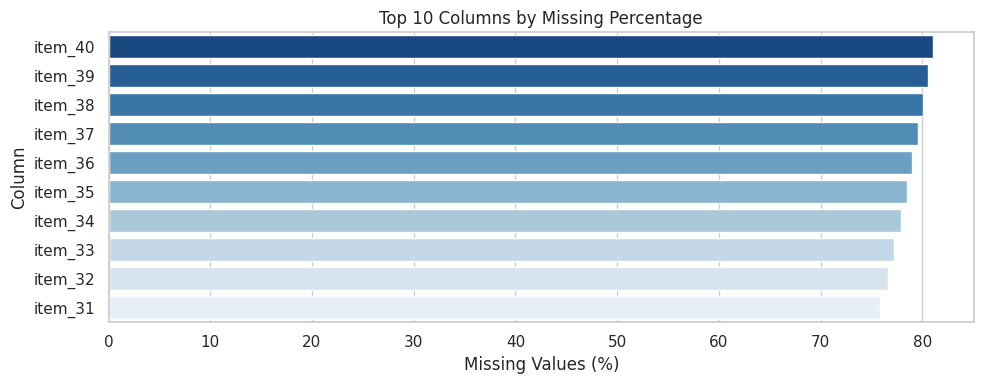

In [ ]:
# Phase 1: Download/load dataset with fallback logic, dataset shape/columns preview, missing-values chart.

data_dir = Path('.')
local_file = data_dir / 'online_retail_new.csv'
fallback_file = data_dir / 'online_retail.csv'
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

if not local_file.exists() and not fallback_file.exists():
    print('Local CSV not found. Downloading Online Retail dataset (XLSX) from UCI...')
    xlsx_file = data_dir / 'online_retail.xlsx'
    if not xlsx_file.exists():
        urllib.request.urlretrieve(url, xlsx_file)
        print(f'Download complete: {xlsx_file}')
    else:
        print(f'Using existing downloaded file: {xlsx_file}')

    df_raw = pd.read_excel(xlsx_file)
    df_raw.to_csv(fallback_file, index=False)
    print(f'Converted XLSX to CSV: {fallback_file}')

file_path = local_file if local_file.exists() else fallback_file
df_raw = pd.read_csv(file_path, sep='\t', encoding='utf-8') if file_path.name == 'online_retail_new.csv' else pd.read_csv(file_path)

print(f'Dataset loaded from: {file_path}')
print(f'Shape: {df_raw.shape}')
print('Columns:', list(df_raw.columns))
display(df_raw.head())

missing_pct = (df_raw.isna().mean().sort_values(ascending=False) * 100).head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Blues_r')
plt.title('Top 10 Columns by Missing Percentage')
plt.xlabel('Missing Values (%)')
plt.ylabel('Column')
plt.tight_layout()
plt.show()

Transactions extracted from row-wise format: 31,941
Approx unique products: 5,289
Avg basket size: 18.92


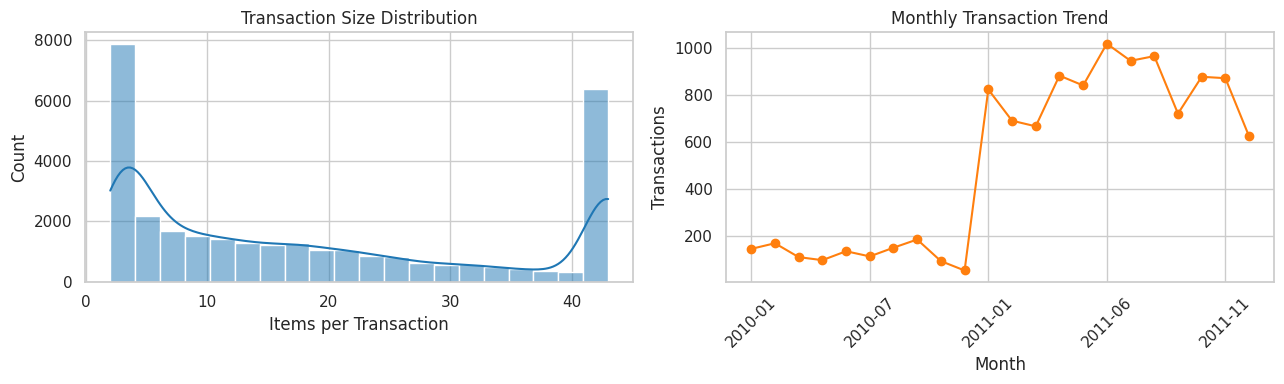

In [13]:
# Phase 2: Transaction preprocessing from either invoice-product logs or row-wise format, basket metrics, transaction-size distribution + trend/top-items chart.

df = df_raw.copy()

rename_map = {c.lower().strip(): c for c in df.columns}
invoice_col = rename_map.get('invoiceno') or rename_map.get('invoice') or rename_map.get('transaction_id')
description_col = rename_map.get('description') or rename_map.get('product') or rename_map.get('item')
quantity_col = rename_map.get('quantity')
invoicedate_col = rename_map.get('invoicedate') or rename_map.get('date')
customer_col = rename_map.get('customerid') or rename_map.get('customer_id')
country_col = rename_map.get('country')
unitprice_col = rename_map.get('unitprice')

if invoice_col and description_col:
    df_clean = df.copy()
    df_clean[description_col] = df_clean[description_col].astype(str).str.strip()
    if quantity_col:
        df_clean = df_clean[pd.to_numeric(df_clean[quantity_col], errors='coerce').fillna(0) > 0]
    if unitprice_col:
        df_clean = df_clean[pd.to_numeric(df_clean[unitprice_col], errors='coerce').fillna(0) > 0]
    df_clean = df_clean[df_clean[description_col].ne('') & df_clean[description_col].ne('nan')]

    transactions = (
        df_clean.groupby(invoice_col)[description_col]
        .apply(lambda x: sorted(set(x)))
        .tolist()
    )
    transaction_sizes = pd.Series([len(t) for t in transactions])

    print(f'Transactions extracted from logs: {len(transactions):,}')
    print(f'Unique products: {df_clean[description_col].nunique():,}')
    print(f'Avg basket size: {transaction_sizes.mean():.2f}')
else:
    df_clean = df.fillna('')
    transactions = df_clean.iloc[:, 1:].values.tolist()
    transactions = [[item for item in transaction if str(item).strip()] for transaction in transactions]
    transaction_sizes = pd.Series([len(t) for t in transactions])

    print(f'Transactions extracted from row-wise format: {len(transactions):,}')
    print(f'Approx unique products: {len(set(sum(transactions, []))):,}')
    print(f'Avg basket size: {transaction_sizes.mean():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(transaction_sizes, bins=20, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Transaction Size Distribution')
axes[0].set_xlabel('Items per Transaction')
axes[0].set_ylabel('Count')

monthly_trans = None
if invoice_col and invoicedate_col and invoice_col in df_clean.columns and invoicedate_col in df_clean.columns:
    dt = pd.to_datetime(df_clean[invoicedate_col], errors='coerce')
    monthly_trans = (
        pd.DataFrame({'invoice': df_clean[invoice_col], 'dt': dt})
        .dropna()
        .assign(month=lambda x: x['dt'].dt.to_period('M').astype(str))
        .drop_duplicates(subset=['invoice'])
        .groupby('month').size()
    )
    monthly_trans.plot(kind='line', marker='o', ax=axes[1], color='#ff7f0e')
    axes[1].set_title('Monthly Transaction Trend')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Transactions')
    axes[1].tick_params(axis='x', rotation=45)
else:
    top_items = pd.Series(sum(transactions, [])).value_counts().head(10)
    sns.barplot(x=top_items.values, y=top_items.index, ax=axes[1], palette='viridis')
    axes[1].set_title('Top 10 Most Frequent Items')
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Item')

plt.tight_layout()
plt.show()

Encoded transaction matrix shape: (31941, 5289)
Density (% of True values): 0.35%
Frequent itemsets found: 537


,support,itemsets,itemset_size
428,0.072728,(WHITE HANGING HEART T-LIGHT HOLDER),1
306,0.068126,(REGENCY CAKESTAND 3 TIER),1
171,0.067061,(JUMBO BAG RED RETROSPOT),1
247,0.053536,(PARTY BUNTING),1
202,0.050562,(LUNCH BAG RED RETROSPOT),1
28,0.046273,(ASSORTED COLOUR BIRD ORNAMENT),1
347,0.045835,(SET OF 3 CAKE TINS PANTRY DESIGN),1
236,0.042297,(PACK OF 72 RETROSPOT CAKE CASES),1
194,0.041076,(LUNCH BAG BLACK SKULL),1
220,0.039886,(NATURAL SLATE HEART CHALKBOARD),1


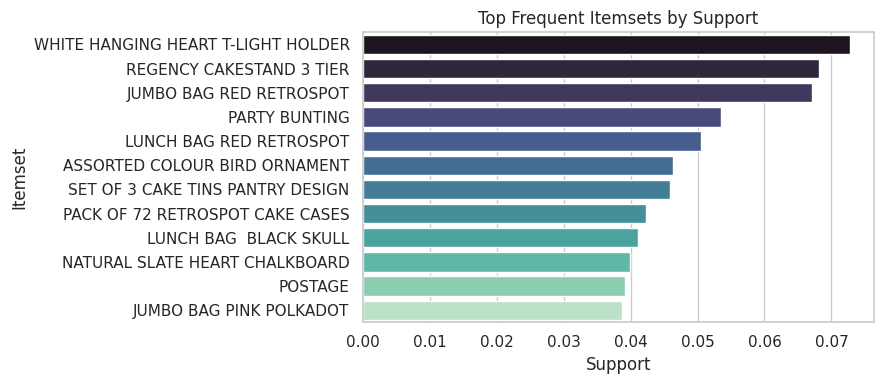

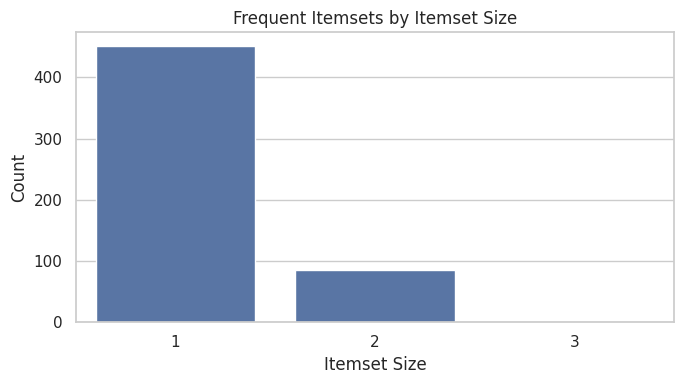

In [14]:
# Phase 3: Transaction encoding, frequent itemset mining with Apriori, itemset size distribution + top itemsets by support chart.

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions, sparse=True)
df_encoded = pd.DataFrame(te_ary.toarray(), columns=te.columns_)

print(f'Encoded transaction matrix shape: {df_encoded.shape}')
print(f'Density (% of True values): {(df_encoded.values.mean() * 100):.2f}%')

min_support = 0.01
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f'Frequent itemsets found: {len(frequent_itemsets):,}')
display(frequent_itemsets.head(15))

plt.figure(figsize=(9, 4))
top_fi = frequent_itemsets.head(12).copy()
top_fi['label'] = top_fi['itemsets'].apply(lambda x: ', '.join(list(x)[:3]) + ('...' if len(x) > 3 else ''))
sns.barplot(data=top_fi, x='support', y='label', palette='mako')
plt.title('Top Frequent Itemsets by Support')
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(data=frequent_itemsets, x='itemset_size', color='#4c72b0')
plt.title('Frequent Itemsets by Itemset Size')
plt.xlabel('Itemset Size')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Rules generated: 165
Avg confidence: 0.430
Avg lift: 14.067
Top recommendation rules:


,antecedents,consequents,support,confidence,lift
140,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.010519,0.781395,47.180622
141,SET/6 RED SPOTTY PAPER PLATES,SET/6 RED SPOTTY PAPER CUPS,0.010519,0.635161,47.180622
138,SMALL MARSHMALLOWS PINK BOWL,SMALL DOLLY MIX DESIGN ORANGE BOWL,0.010613,0.743421,44.301515
139,SMALL DOLLY MIX DESIGN ORANGE BOWL,SMALL MARSHMALLOWS PINK BOWL,0.010613,0.632463,44.301515
103,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.011834,0.726923,42.292623
104,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.011834,0.688525,42.292623
20,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",PINK REGENCY TEACUP AND SAUCER,0.016530,0.696570,27.742070
21,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.016530,0.658354,27.742070
162,HAND WARMER OWL DESIGN,HAND WARMER SCOTTY DOG DESIGN,0.010175,0.484352,27.527897
161,HAND WARMER SCOTTY DOG DESIGN,HAND WARMER OWL DESIGN,0.010175,0.578292,27.527897


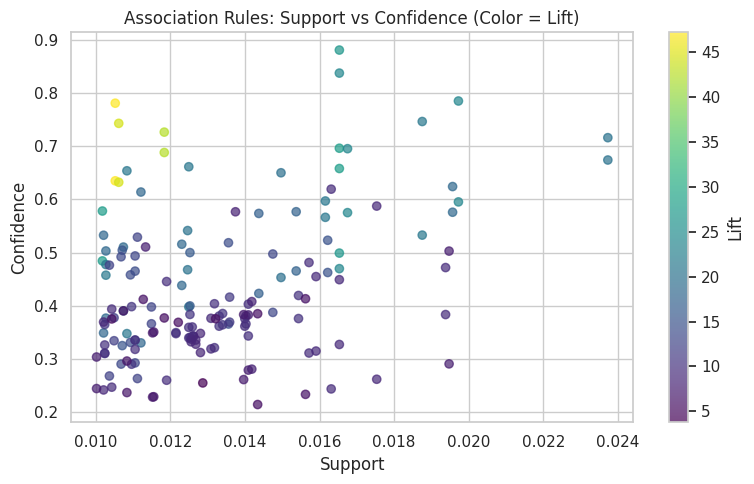

In [15]:
# Phase 4: Association rule generation with confidence/lift thresholds, rules preview, support-confidence-lift scatter chart.

min_confidence = 0.2
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=min_confidence)

if rules.empty:
    print('No association rules generated. Try lower min_support or min_confidence.')
else:
    rules = rules.sort_values(['lift', 'confidence'], ascending=False)
    print(f'Rules generated: {len(rules):,}')
    print(f"Avg confidence: {rules['confidence'].mean():.3f}")
    print(f"Avg lift: {rules['lift'].mean():.3f}")

    rules_view = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    rules_view['antecedents'] = rules_view['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
    rules_view['consequents'] = rules_view['consequents'].apply(lambda x: ', '.join(sorted(list(x))))

    print('Top recommendation rules:')
    display(rules_view.head(15))

    plt.figure(figsize=(8, 5))
    sc = plt.scatter(
        rules['support'],
        rules['confidence'],
        c=rules['lift'],
        cmap='viridis',
        alpha=0.7
    )
    plt.colorbar(sc, label='Lift')
    plt.title('Association Rules: Support vs Confidence (Color = Lift)')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.tight_layout()
    plt.show()